<a href="https://colab.research.google.com/github/shriya-dev-ui/lab1aiml/blob/main/bfs_dfsp1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install networkx matplotlib

BFS Traversal: A -> B -> C -> D -> E -> F
DFS Traversal: A -> B -> D -> E -> C -> F


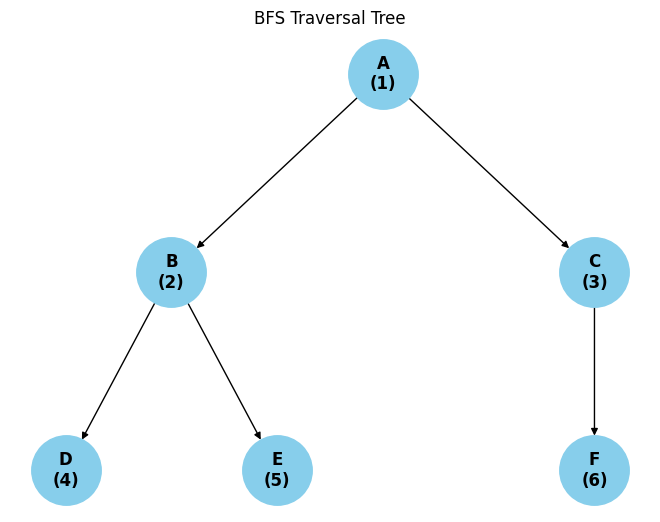

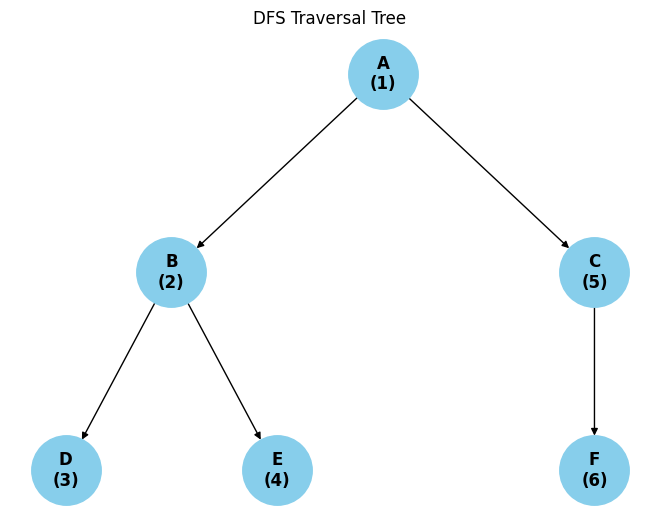

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import deque

graph = {
    'A': ['B', 'C'],
    'B': ['D', 'E'],
    'C': ['F'],
    'D': [],
    'E': [],
    'F': []
}

def bfs(graph, start):
    visited = set()
    queue = deque([start])
    visited.add(start)

    order = []
    edges = []

    while queue:
        node = queue.popleft()
        order.append(node)

        for neighbour in graph[node]:
            if neighbour not in visited:
                visited.add(neighbour)
                queue.append(neighbour)
                edges.append((node, neighbour))

    return order, edges

def dfs(graph, start):
    visited = set()
    order = []
    edges = []

    def dfs_recursive(node):
        visited.add(node)
        order.append(node)

        for neighbour in graph[node]:
            if neighbour not in visited:
                edges.append((node, neighbour))
                dfs_recursive(neighbour)

    dfs_recursive(start)

    return order, edges


bfs_order, bfs_edges = bfs(graph, 'A')
dfs_order, dfs_edges = dfs(graph, 'A')

print("BFS Traversal:", " -> ".join(bfs_order))
print("DFS Traversal:", " -> ".join(dfs_order))



def draw_tree(edges, order, title):

    G = nx.DiGraph()
    G.add_edges_from(edges)

    pos = {
        'A': (0, 2),
        'B': (-1, 1),
        'C': (1, 1),
        'D': (-1.5, 0),
        'E': (-0.5, 0),
        'F': (1, 0)
    }

    nx.draw(
        G,
        pos,
        with_labels=False,
        node_color="skyblue",
        node_size=2500,
        edge_color="black",
        arrows=True
    )

    labels = {
        node: f"{node}\n({i + 1})"
        for i, node in enumerate(order)
    }

    nx.draw_networkx_labels(
        G,
        pos,
        labels=labels,
        font_size=12,
        font_weight="bold"
    )

    plt.title(title)
    plt.axis("off")
    plt.show()


draw_tree(bfs_edges, bfs_order, "BFS Traversal Tree")

draw_tree(dfs_edges, dfs_order, "DFS Traversal Tree")
